In [3]:
import cv2
import time
import matplotlib.pyplot as plt

from insightface.app import FaceAnalysis

### 모델 로드

In [4]:
app = FaceAnalysis(
    name='buffalo_l',
    providers=['CPUExecutionProvider']
)

app.prepare(
    ctx_id=-0,
    det_size=(640,640)
)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112]

### 이미지 읽기

In [5]:
img = cv2.imread("../images/test1.jpg")

### Detection 모델만 가져오기

In [6]:
detector = app.models['detection']

### Detection 시간 측정

In [7]:
start = time.perf_counter()

bboxes, kpss = detector.detect(img)

end = time.perf_counter()

elapsed = end - start

### Bounding Box 시각화

In [8]:
for i in range(len(bboxes)):

    bbox = bboxes[i][:4]

    x1 = int(bbox[0])
    y1 = int(bbox[1])
    x2 = int(bbox[2])
    y2 = int(bbox[3])

    cv2.rectangle(
        img,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        2
    )

### 박스 및 detection 시간 출력

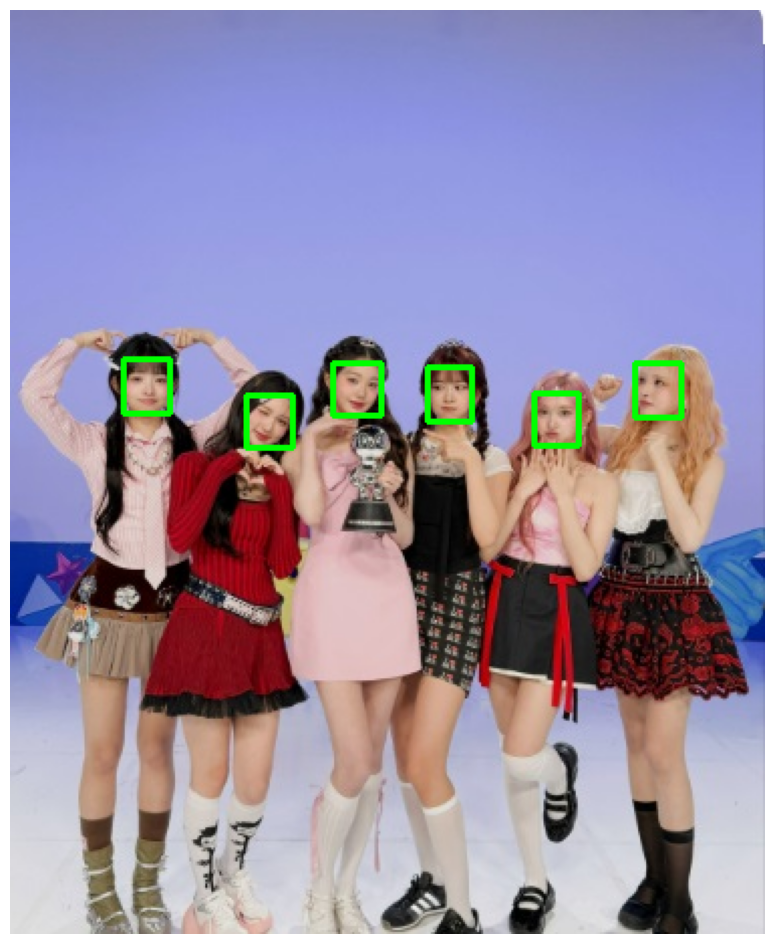

검출된 얼굴 수 : 6
검출 시간 : 137.44 ms (0.14 sec)


In [9]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,12))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

print(f"검출된 얼굴 수 : {len(bboxes)}")
print(f"검출 시간 : {elapsed*1000:.2f} ms ({elapsed:.2f} sec)")